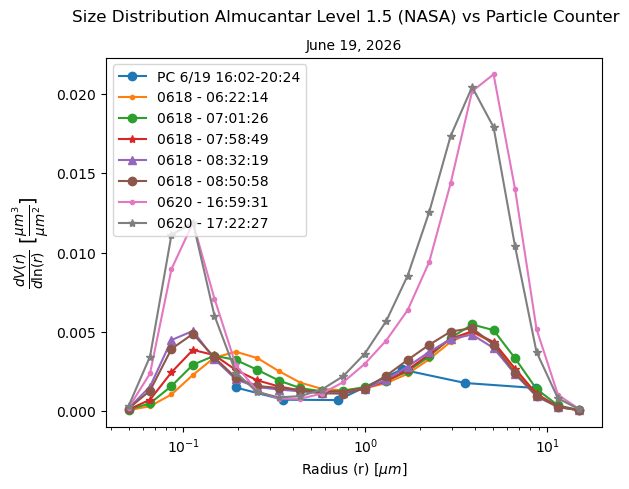

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NASA Aeronet Data:
data = pd.read_csv('20260618_Rexburg_Idaho.csv')
data1 = pd.read_csv('20260620_Rexburg_Idaho.csv')

y1 = data.iloc[0,5:27].values
y2 = data.iloc[1,5:27].values
y3 = data.iloc[2,5:27].values
y4 = data.iloc[3,5:27].values
y5 = data.iloc[4,5:27].values

y6 = data1.iloc[0,5:27].values
y7 = data1.iloc[1,5:27].values

x = data.columns[5:27].astype(float).values

# Particle Counter (PC) Calculation:
particle = pd.read_csv('Particle_Counter_Data_June_19_2026_Flight.csv')
alt = pd.read_csv('AltitudeData06.19.csv')

particle['Time'] = pd.to_datetime(particle['Time'], errors='coerce')
alt['Time'] = pd.to_datetime(alt['time'], format="%m/%d/%y %H:%M", errors='coerce')

particle_strip = particle[(particle['Time']>=alt['Time'].min()) & (particle['Time']<=alt['Time'].max())]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()

z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

plt.plot(r_mid,py,'o-',label='PC 6/19 16:02-20:24')
plt.plot(x, y1, '.-', label="0618 - 06:22:14")
plt.plot(x, y2, 'o-', label="0618 - 07:01:26")
plt.plot(x, y3, '*-', label="0618 - 07:58:49")
plt.plot(x, y4, '^-', label="0618 - 08:32:19")
plt.plot(x, y5, 'o-', label="0618 - 08:50:58")
plt.plot(x, y6, '.-', label="0620 - 16:59:31")
plt.plot(x, y7, '*-', label="0620 - 17:22:27")       
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 (NASA) vs Particle Counter')
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()

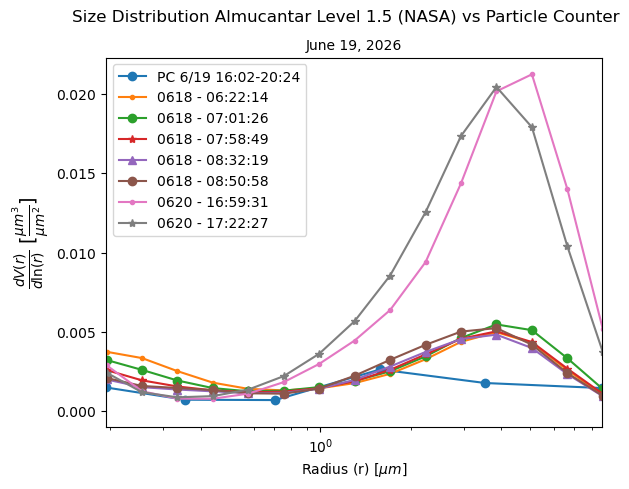

In [6]:
plt.plot(r_mid,py,'o-',label='PC 6/19 16:02-20:24')
plt.plot(x, y1, '.-', label="0618 - 06:22:14")
plt.plot(x, y2, 'o-', label="0618 - 07:01:26")
plt.plot(x, y3, '*-', label="0618 - 07:58:49")
plt.plot(x, y4, '^-', label="0618 - 08:32:19")
plt.plot(x, y5, 'o-', label="0618 - 08:50:58")
plt.plot(x, y6, '.-', label="0620 - 16:59:31")
plt.plot(x, y7, '*-', label="0620 - 17:22:27") 
plt.xlim(min(r_mid),max(r_mid))
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle('Size Distribution Almucantar Level 1.5 (NASA) vs Particle Counter')
plt.title("June 19, 2026", fontsize=10)
plt.legend()
plt.show()